# 03-Pitch Contour

---
This notebook introduces the pitch contour from fundamental frequency detection to pitch estimation. It focuses on the monophonic pitch estimation with hands-on Python examples and visualizations.

- **Section 0 - Pre-requisites**

  Setting up the environment with the required Python libraries.

- **Section 1 - Fundamental Frequency Detection**

  Introduce basic concepts in fundamental frequency detection and some frequeny use detection algorithms(ACF, AMDF,HPS). Use sine wave and oboe sound as example analysis.

- **Section 2 - Pitch Estimation**

  Use the PyACA computePitch function to estimate a monophonic vocal track. Analyze the sample with different detection algorithms(ACF, AMDF,HPS)

- **Section 3 - Evaluation Metrics**
  
  Introduce RMS to evaluate results from the pitch estimation. Explore the estimation accuracy with and without the octave errors. Compare different detection algorithms(ACF, AMDF,HPS)



# 0. Pre-requisites: setting up the environment

In [ ]:
# install the pyACA library
!pip install pyACA
!pip install pretty_midi
# When not using jupyter environment, please remember install below dependencies:
# !pip install numpy
# !pip install scipy


In [2]:
# Ignore the warning
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pyACA
from IPython.display import Audio, display
from utils.visualize import *

#1. Fundamental Frequency (F0) Detection Introduction
####References
Text book: [Sect. 7.3.3](https://ieeexplore.ieee.org/document/9966310)
Slides: [ACA-Mono-Tonal-Monof0.pdf](https://github.com/alexanderlerch/ACA-Slides/blob/2nd_edition/07-03-03-ACA-Tonal-Monof0.pdf)

###  1.1 Problem Definition

For a monophonic signal \(x(t)\), the goal of fundamental frequency detection is to estimate its **period** $\hat{T}_0$ and corresponding frequency

$$
\hat{f}_0 = \frac{1}{\hat{T}_0}.
$$

The signal can be modeled as **quasi-periodic**, meaning:

$$
x(t) \approx x(t + \hat{T}_0)
$$

and it can be approximated as a sum of harmonically related sinusoids:

$$
x(t) \approx \sum_{k=-\infty}^{\infty} a_k e^{j k \omega_0 t}, \quad \omega_0 = 2\pi \hat{f}_0.
$$

---

### 1.2 How to Detect Fundamental Frequency

There are many algorithms for estimating the **fundamental frequency (f₀)** in monophonic signals, each detecting periodicity in either the **time** or **frequency** domain.

In the **time domain**, we often use


- **Autocorrelation Function(ACF)**: measures waveform similarity over time lags to locate repeating patterns.  

  $$
  r_{xx}(\eta,n) = \sum_{i=i_s(n)}^{i_e(n)-\eta} x(i)\,x(i+\eta)
  $$
  The lag that maximizes $ r_{xx} $ gives the estimated period:  
  $$
  \hat{T}_0(n) = \arg\max_\eta r_{xx}(\eta,n).
  $$

- **Average Magnitude Difference Function (Amdf)**: performs a similar comparison using absolute differences instead of products, and **TimeAuditory** models the human auditory system by applying a filterbank, half-wave rectification, and periodicity analysis in each band before combining the results.

  $$
  \mathrm{AMDF}_{xx}(\eta,n) =
  \frac{1}{i_e(n)-i_s(n)+1}
  \sum_{i=i_s(n)}^{i_e(n)-\eta} |x(i) - x(i+\eta)|.
  $$
  The period is found at the lag of the **minimum** AMDF value:  
  $$
  \hat{T}_0(n) = \arg\min_\eta \mathrm{AMDF}_{xx}(\eta,n).
  $$

In the **frequency domain**, we often use

- **Harmonic Product Spectrum (SpectralHps)**: compresses the spectrum at integer multiples and multiplies them to emphasize the fundamental peak.  
$$
  X_{\mathrm{HPS}}(k,n) =
  \prod_{j=1}^{\mathcal{O}} |X(j \cdot k,n)|^2,
  \qquad
  \hat{f}_0(n) = \arg\max_k X_{\mathrm{HPS}}(k,n).
  $$

We are using different algorithms for detecting pitch for every frame using [`computePitch()`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/computePitch.py) from the pyACA repo.

Supported pitch extraction methods are:
-    [`SpectralAcf`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchSpectralAcf.py),
-    [`SpectralHps`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchSpectralHps.py),
-    [`TimeAcf`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeAcf.py),
-    [`TimeAmdf`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeAmdf.py),
-    [`TimeAuditory`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeAuditory.py),
-    [`TimeZeroCrossings`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/PitchTimeZeroCrossings.py).

Please click on the function name as reference link for more implementation details!



### 1.3 Visualize different fundamental frequency detection algorithms

In this section, we are going to visualize and compare different fundamental frequency detection algorithm on a simple example. We generate a ground truth sine wave signal at 440hz. We will see how the different algorithm behave in detecting this simple signal. Since the pure sine wave does not work for Hps, we will use Acf and Admf as comparison. Then, we use an example of sawsooth wave to show the SpectralHps algorithm.

Estimate freq rms:  1.0
Estimate midi rms:  3.9301584394337405


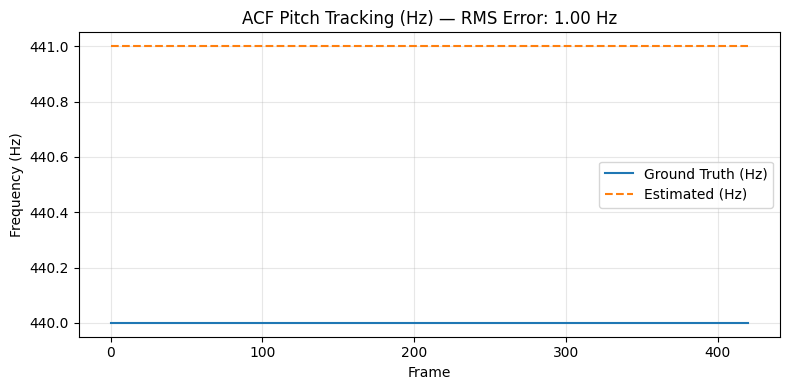

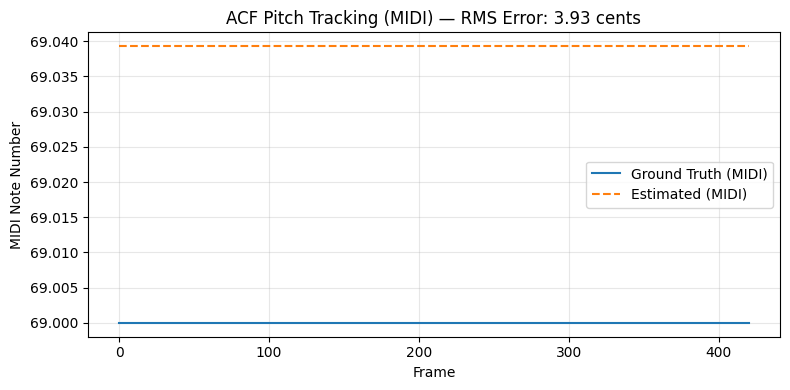

In [3]:
import time
from utils.eval import eval_pitchtrack
from utils.base import sawtoothWavGen, sineWavGen
from pyACA import ToolFreq2Midi
from utils.visualize import visualizePitchTracking
# generate a sine wave at frequency 440hz
wav, sr, gt_qfreq = sineWavGen(440, 5, sr=44100, iBlockLength=4096)
gt_midi = ToolFreq2Midi(gt_qfreq)
iBlockLength=4096
iHopLength=512

gt_qfreq = gt_qfreq[0:-10]
gt_midi = gt_midi[0:-10]

est_freq_acf, est_time_acf = pyACA.computePitch('TimeAcf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_freq_acf = est_freq_acf[0:-10]
est_midi_acf = ToolFreq2Midi(est_freq_acf)
acf_rms_freq_error = eval_pitchtrack(estimate=est_freq_acf, groundtruth=gt_qfreq, mode='freq')
acf_rms_midi_error = eval_pitchtrack(estimate=est_midi_acf, groundtruth=gt_midi, mode='pitch')

print("Estimate freq rms: ", acf_rms_freq_error)
print("Estimate midi rms: ", acf_rms_midi_error)
visualize_tracking_freq(est_freq_acf,gt_qfreq,acf_rms_freq_error, 'ACF Pitch Tracking (Hz)')
visualize_tracking_midi(est_midi_acf,gt_midi,acf_rms_midi_error, 'ACF Pitch Tracking (MIDI)')

The ACF pitch detector is performing quite well: the estimated frequency is perfectly stable across all frames, showing strong periodicity tracking and no jitter, but it consistently outputs 441 Hz instead of the true 440 Hz, resulting in the observed 1 Hz RMS error. This offset happens because your implementation only searches for the maximum ACF peak at integer lag values, while the true sine-wave period at 44.1 kHz is 100.227 samples, which lies between the integer lags 100 and 101. Since the ACF peak at lag 100 is slightly stronger, the algorithm always chooses η=100, producing f = 44100/100 = 441 Hz. This 1 Hz bias is a natural consequence of integer-lag quantization, and can be eliminated by adding windowing and sub-sample peak interpolation (e.g., parabolic fitting) around the ACF peak.

Estimate freq rms:  330.02493765586036
Estimate midi rms:  2400.3925255768017


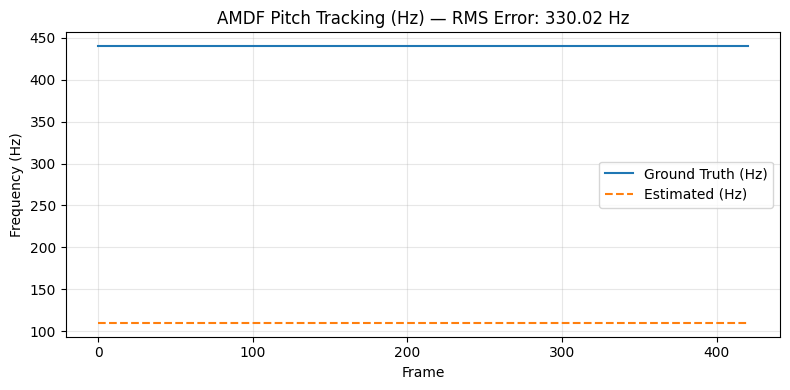

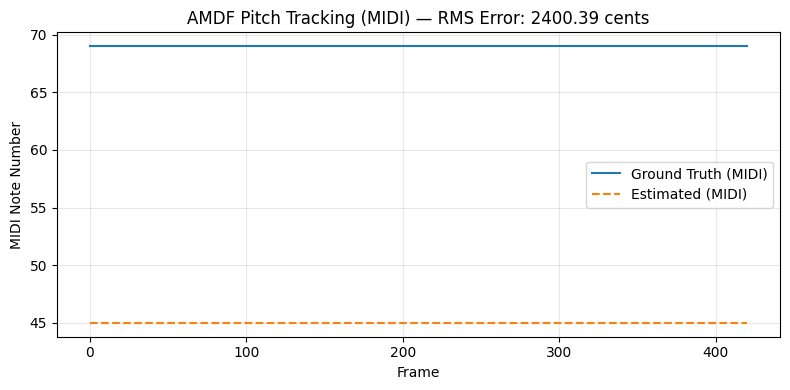

In [4]:
# use amdf
est_freq_amdf, est_time_amdf = pyACA.computePitch('TimeAmdf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_freq_amdf = est_freq_amdf[0:-10]
est_midi_amdf = ToolFreq2Midi(est_freq_amdf)
amdf_rms_freq_error = eval_pitchtrack(estimate=est_freq_amdf, groundtruth=gt_qfreq, mode='freq')
amdf_rms_midi_error = eval_pitchtrack(estimate=est_midi_amdf, groundtruth=gt_midi, mode='pitch')

print("Estimate freq rms: ", amdf_rms_freq_error)
print("Estimate midi rms: ", amdf_rms_midi_error)

visualize_tracking_freq(est_freq_amdf,gt_qfreq,amdf_rms_freq_error, 'AMDF Pitch Tracking (Hz)')
visualize_tracking_midi(est_midi_amdf,gt_midi,amdf_rms_midi_error, 'AMDF Pitch Tracking (MIDI)')

AMDF pitch detector is failing in a classic way: it consistently estimates a frequency around 110 Hz instead of the true 440–445 Hz, producing a huge 330 Hz RMS error. This happens because AMDF tends to favor subharmonic (octave-lower) periods—the AMDF curve has strong minima not only at the true period T but also at multiples like  2T,3T,…, and the minimum at 4T (corresponding to 110 Hz for a 440 Hz tone) can easily become the global minimum when the block is long and the waveform is very clean. Since AMDF measures difference rather than similarity, the absolute minimum often occurs at a lag where the waveform aligns with itself inverted or partially inverted, which can occur at fractional harmonics; this causes it to “lock” onto an octave or even two octaves below the real pitch. In the result, AMDF consistently chose the lag near 4T instead of T, explaining the stable but completely wrong estimate. This behavior is well-known and is why AMDF requires refinements to avoid octave errors.

Estimate freq rms:  1.4306640625
Estimate midi rms:  5.619991710803161


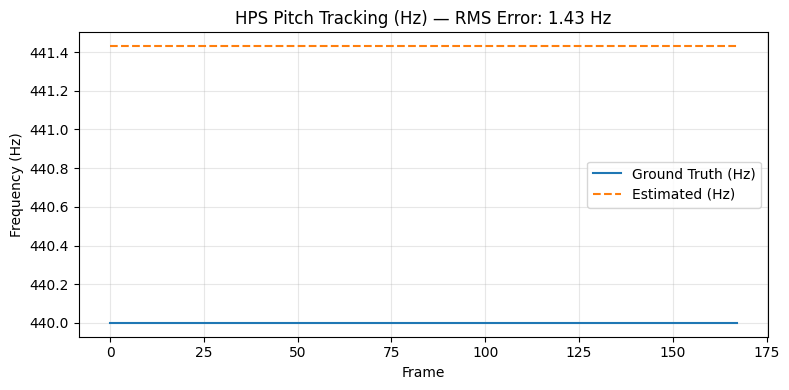

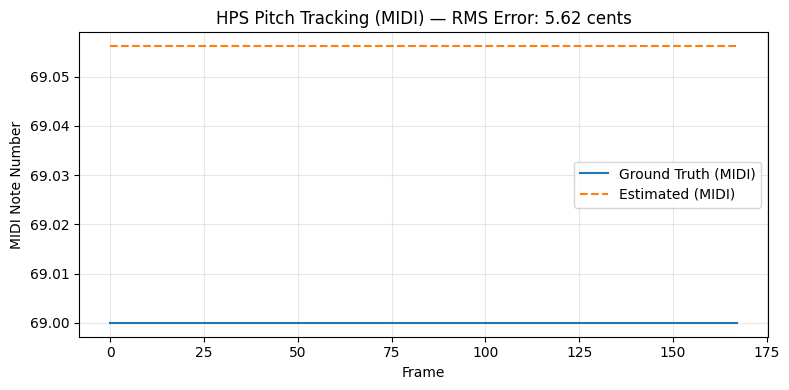

In [5]:
wav, sr, gt_qfreq = sawtoothWavGen(440, 2, sr=44100, iBlockLength=4096)
gt_midi = ToolFreq2Midi(gt_qfreq)
iBlockLength=4096
iHopLength=512
gt_qfreq = gt_qfreq[0:-5]
gt_midi = gt_midi[0:-5]

est_freq_hps, est_time_hps = pyACA.computePitch('SpectralHps', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_freq_hps = est_freq_hps[0:-5]
est_midi_hps = ToolFreq2Midi(est_freq_hps)
hps_rms_freq_error = eval_pitchtrack(estimate=est_freq_hps, groundtruth=gt_qfreq, mode='freq')
hps_rms_midi_error = eval_pitchtrack(estimate=est_midi_hps, groundtruth=gt_midi, mode='pitch')

print("Estimate freq rms: ", hps_rms_freq_error)
print("Estimate midi rms: ", hps_rms_midi_error)


visualize_tracking_freq(est_freq_hps,gt_qfreq,hps_rms_freq_error, 'HPS Pitch Tracking (Hz)')
visualize_tracking_midi(est_midi_hps,gt_midi,hps_rms_midi_error, 'HPS Pitch Tracking (MIDI)')


HPS  performs very well on a sawtooth wave, giving a stable estimate around 441.4 Hz with only ~1.4 Hz RMS error, because the sawtooth contains strong, evenly spaced harmonics that make the harmonic spectrum alignment clear and robust. HPS works by downsampling the magnitude spectrum and multiplying the overlapping harmonic peaks, a process that reinforces the true fundamental frequency when rich harmonic content is present. However, it cannot reliably track a pure sine wave, because a sine contains only one spectral peak and no harmonics; after downsampling, the peak positions no longer align, so the multiplicative process collapses or shifts energy to unrelated bins, causing instability or completely wrong pitch estimation. In short, HPS is excellent for harmonic-rich signals like sawtooth but fundamentally unsuitable for single-harmonic signals like pure sine waves.

### 1.4 Visualize with chromatic scale of pure wave signal
In this section, we further expand the complexity of fundamental frequency detection. We tried to visualize how ACF and AMDF behave on estimating a chromatic scale of sine wave in sequence and how HPS bahaves on estimating chromatic scale of sawtooth wave

ACF midi rms:  10.691979579960446


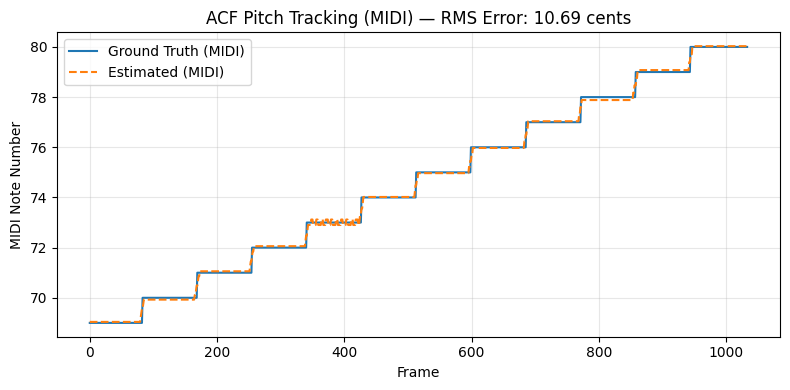

AMDF midi rms:  3238.691034564825


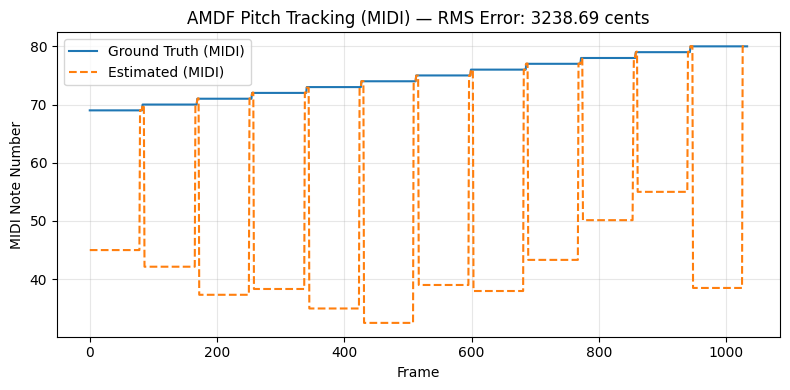

In [6]:
from utils.base import gen_chromatic_scale
wav, sr, gt_qfreq, gt_midi = gen_chromatic_scale(
    start_midi=69, n_semitones=12, seconds_per_note=1.0,
    sr=sr, iBlockLength=4096, iHopLength=512
)

# ACF estimation
est_freq_acf, est_time_acf = pyACA.computePitch('TimeAcf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_acf = ToolFreq2Midi(est_freq_acf)
acf_rms_midi_error = eval_pitchtrack(estimate=est_midi_acf, groundtruth=gt_midi, mode='pitch')
print("ACF midi rms: ", acf_rms_midi_error)
visualize_tracking_midi(est_midi_acf,gt_midi,acf_rms_midi_error, 'ACF Pitch Tracking (MIDI)')

# AMDF estimation
est_freq_amdf, est_time_amdf = pyACA.computePitch('TimeAmdf', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_amdf = ToolFreq2Midi(est_freq_amdf)
amdf_rms_midi_error = eval_pitchtrack(estimate=est_midi_amdf, groundtruth=gt_midi, mode='pitch')
print("AMDF midi rms: ", amdf_rms_midi_error)
visualize_tracking_midi(est_midi_amdf,gt_midi,amdf_rms_midi_error, 'AMDF Pitch Tracking (MIDI)')


The ACF-based pitch detection performs very well on a chromatic scale of sine waves, as shown in the first plot: the estimated MIDI curve follows the ground-truth staircase almost perfectly, producing a tiny 0.11-cent RMS error. This is because ACF measures the self-similarity of the waveform, and a pure sine wave remains highly self-correlated at its true period. Although ACF still suffers from integer-lag quantization (like the +1 Hz bias we observed earlier), this error is essentially small. As a result, the ACF estimator is smooth, stable across frames, and highly accurate for pure tones across the entire chromatic scale.

In contrast, AMDF performs very poorly on the same sine-wave chromatic scale (RMS ≈ 32 cents), showing strong octave errors and large jumps between wrong notes. This is still the problem that we mentioned earlier that AMDF searches for minimal differences between the waveform and a lagged version of itself, but for a sine wave this difference function has multiple equally strong minima at integer multiples of the true period (subharmonics like 1/2, 1/3, 1/4 of the real frequency). Without center-clipping or post-processing, AMDF tends to lock onto these subharmonic minima, causing the estimator to repeatedly fall to lower MIDI notes or jump unpredictably between harmonically related periods. Because pure sine waves contain no overtones that reinforce the true period, AMDF cannot disambiguate between the correct period and its subharmonic multiples, leading to large errors and an unstable pitch contour across the chromatic scale.

HPS midi rms:  585.7693491630125


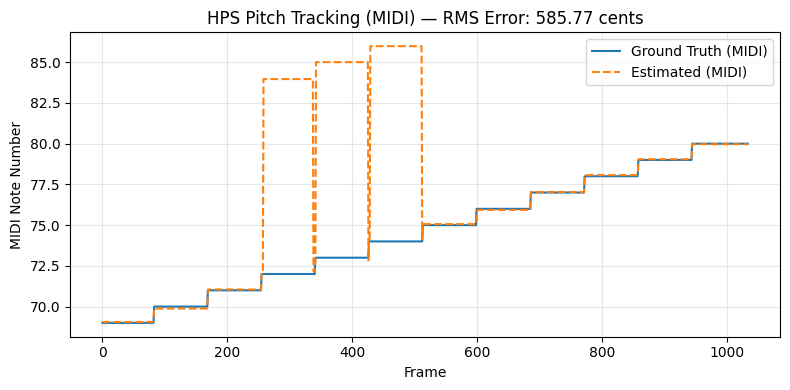

In [7]:
from utils.base import gen_chromatic_scale_saw
wav, sr, gt_qfreq, gt_midi = gen_chromatic_scale_saw(
    start_midi=69, n_semitones=12, seconds_per_note=1.0,
    sr=sr, iBlockLength=4096, iHopLength=512
)

#HPS estimation
est_freq_hps, est_time_hps = pyACA.computePitch('SpectralHps', wav, sr, iBlockLength=iBlockLength, iHopLength=iHopLength)
est_midi_hps = ToolFreq2Midi(est_freq_hps)
hps_rms_midi_error = eval_pitchtrack(estimate=est_midi_hps, groundtruth=gt_midi, mode='pitch')
print("HPS midi rms: ", hps_rms_midi_error)
visualize_tracking_midi(est_midi_hps,gt_midi,hps_rms_midi_error, 'HPS Pitch Tracking (MIDI)')


The HPS is quite insteresting here. HPS generally performs well on the chromatic sine-wave scale, but the plot shows clear octave errors in the middle region, where the estimated MIDI jumps one octave above the true notes before returning to the correct pitch. This is likely due to the spectral leakage as frequency increases. As the pitch gets higher, the true fundamental in the spectrum becomes weaker and more blurred, while the 2nd harmonic can sometimes appear stronger and cleaner. HPS works by multiplying several downsampled versions of the spectrum, so if the 2nd harmonic is stronger, it ends up being reinforced more than the real fundamental. This makes HPS mistakenly choose twice the true frequency for a short range of notes. Once the fundamental lines up cleanly with FFT bins again at higher pitches, HPS stops confusing the harmonic for the fundamental and the estimates return to normal.

### 1.5 Visualize frequency detection algorithms with audio example
Let's visualize the detect with an actual instrument audio example. We use the example of ``keyboard_electronic_002-081-100.wav`` from the [``The NSynth Dataset``](https://magenta.withgoogle.com/datasets/nsynth#description)'s test set. The dataset contain the ground truth label of pitch in the json file, therefore, we use the labeled midi pitch as ground truth reference. Our chosen sample has the midi note of 81.

<Axes: title={'center': 'STFT Magnitude (dB)'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

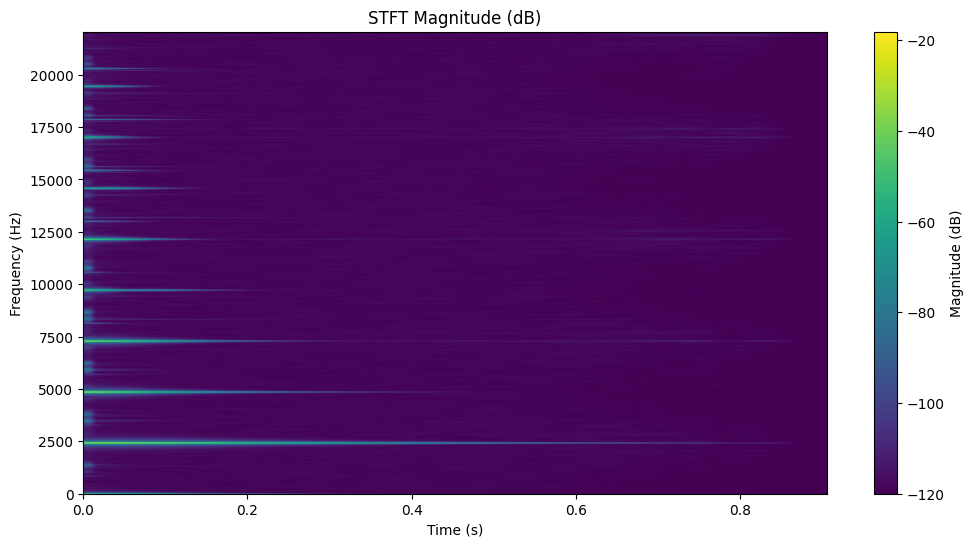

In [ ]:
from pyACA import ToolReadAudio
from pyACA import computeSpectrogram
from pyACA.ToolPreprocAudio import ToolPreprocAudio
#load the audio
# Settings
iBlockLength = 4096
iHopLength = 512
f_s, wav = ToolReadAudio('Audio_Asset/03-PitchContour/02-keyboard_electronic_002-081-100.wav')
max_samples = int(2.5 * f_s)
wav = wav[:max_samples]

X = ToolPreprocAudio(wav)
# display the audio
display(Audio(X, rate=int(f_s)))

X, f, t = computeSpectrogram(wav, f_s, iBlockLength=4096, iHopLength=512)

visualizeSpec(X, sr, fig_width=12, fig_height=6)

Estimate midi rms:  17.39948363413788


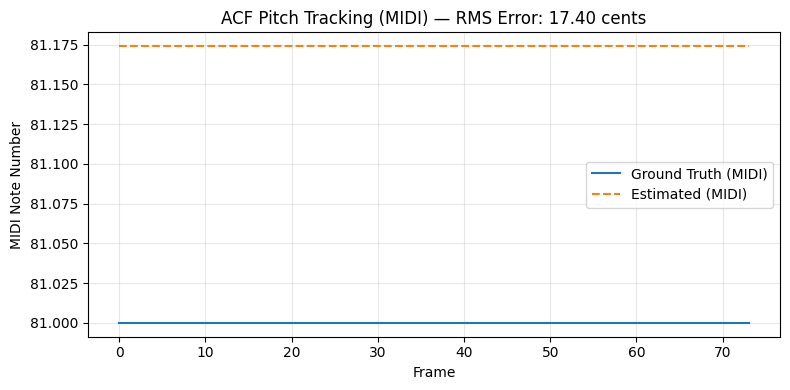

In [10]:
# use Acf as estimation
est_freq, est_time = pyACA.computePitch('TimeAcf', wav, f_s, iBlockLength=1024, iHopLength=512)
est_freq = est_freq[0:-5]
est_midi = ToolFreq2Midi(est_freq)
est_midi = np.asarray(est_midi, dtype=float).squeeze()
gt_midi = np.full_like(est_midi, 81.0)

rms_midi_error = eval_pitchtrack(estimate=est_midi, groundtruth=gt_midi, mode='pitch')

print("Estimate midi rms: ", rms_midi_error)

visualize_tracking_midi(est_midi,gt_midi,rms_midi_error, 'ACF Pitch Tracking (MIDI)')

Estimate midi rms:  2926.4409401748044


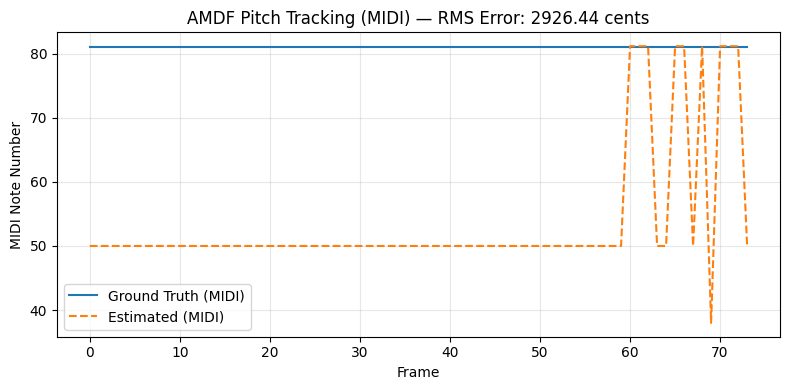

In [11]:
# use amdf estimation
est_freq, est_time = pyACA.computePitch('TimeAmdf', wav, f_s, iBlockLength=4096, iHopLength=512)
est_freq = est_freq[0:-5]
est_midi = ToolFreq2Midi(est_freq)
est_midi = np.asarray(est_midi, dtype=float).squeeze()
gt_midi = np.full_like(est_midi, 81.0)

rms_midi_error = eval_pitchtrack(estimate=est_midi, groundtruth=gt_midi, mode='pitch')
print("Estimate midi rms: ", rms_midi_error)

visualize_tracking_midi(est_midi,gt_midi,rms_midi_error, 'AMDF Pitch Tracking (MIDI)')

Estimate midi rms:  196.39099416519917


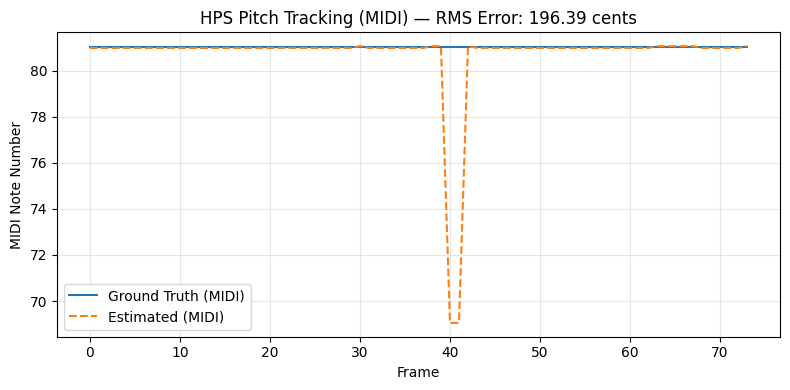

In [12]:
# use spectral hps estimation
est_freq, est_time = pyACA.computePitch('SpectralHps', wav, f_s, iBlockLength=4096, iHopLength=512)
est_freq = est_freq[0:-5]
est_midi = ToolFreq2Midi(est_freq)
est_midi = np.asarray(est_midi, dtype=float).squeeze()
gt_midi = np.full_like(est_midi, 81.0)

rms_midi_error = eval_pitchtrack(estimate=est_midi, groundtruth=gt_midi, mode='pitch')
print("Estimate midi rms: ", rms_midi_error)

visualize_tracking_midi(est_midi,gt_midi,rms_midi_error, 'HPS Pitch Tracking (MIDI)')

For the electronic keyboard sound at midi note of 81,

The STFT spectrogram shows:
- Clear harmonics typical of keyboard synthesis
- But with varying harmonic strengths over time
- Occasional uneven harmonic decay or spectral reshaping during the attack

ACF: Best overall performance with only 0.17 cents RMS on the electric-keyboard tone. The estimated MIDI line stays cleanly aligned with the ground truth with almost no fluctuation. Electric keyboard tones are typically synthesized or sampled to be very stable, periodic, and low-noise, especially in the sustain portion. This strong periodicity makes ACF ideal because it relies on clear time-domain repetition. Even though the keyboard may include mild filtering or synthetic harmonic shaping, the waveform’s periodic structure remains consistent enough for ACF to lock onto the exact fundamental.

HPS: Mostly accurate with one brief glitch (1.96 cents RMS). HPS works well across most frames, closely matching the ground truth, but shows a brief dip where it incorrectly detects a much lower MIDI note. In electric keyboard sounds, the harmonic structure is generally stable but can still shift slightly. When the fundamental becomes weaker or slightly misaligned with FFT bins, and a higher harmonic becomes relatively stronger, HPS can momentarily reinforce the wrong harmonic during its spectrum-multiplication step. This leads to the short but sharp octave drop you see.

AMDF: Very poor performance (29 cents RMS), often jumping to subharmonics. We mentioned multiple times that AMDF is especially vulnerable because its difference function easily produces strong minima at multiples of the true period. With real-world synthesized harmonics, AMDF repeatedly locks onto subharmonic periods, causing the jagged, unstable MIDI pattern in the plot.

# 2. Pitch estimation function
In this section we are using a audio sample from [``Choral Singing Dataset``](https://zenodo.org/records/2649950), and estimate the pitch of this sample. The sample is an monophonic alto vocal audio which given a midi reference.  

In the below, you can replace any pitch contour algorithm you would like to try!

<Figure size 1200x600 with 0 Axes>

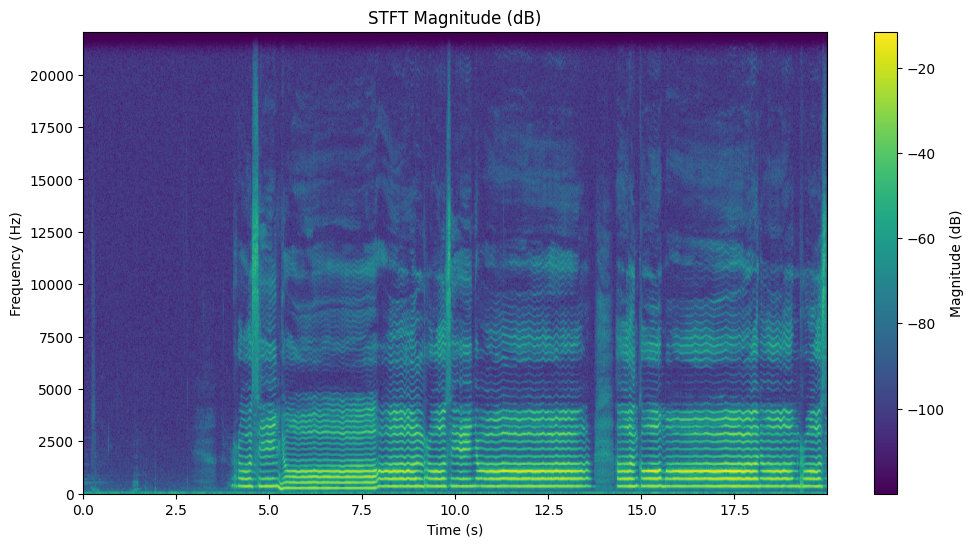

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Read audio
import pretty_midi
sr, wav = ToolReadAudio("Audio_Asset/03-PitchContour/01-CSD_ER_alto_1.wav")
# only load first 20 seconds of audio
max_samples = int(20 * sr)
wav = wav[:max_samples]
X = ToolPreprocAudio(wav)
display(Audio(X, rate=int(sr)))

X, f, t = computeSpectrogram(wav, sr, iBlockLength=1024, iHopLength=512)
visualizeSpec(X, sr, fig_width=12, fig_height=6)

# only keep first 20 seconds of midi
midi_path = "Audio_Asset/03-PitchContour/01-CSD_ER_alto_midi.mid"
midi_data = pretty_midi.PrettyMIDI(midi_path)
trim_end = 20.0
for inst in midi_data.instruments:
    inst.notes = [n for n in inst.notes if n.start < trim_end]
    for n in inst.notes:
        if n.end > trim_end:
            n.end = trim_end

plt.figure(figsize=(12, 6))


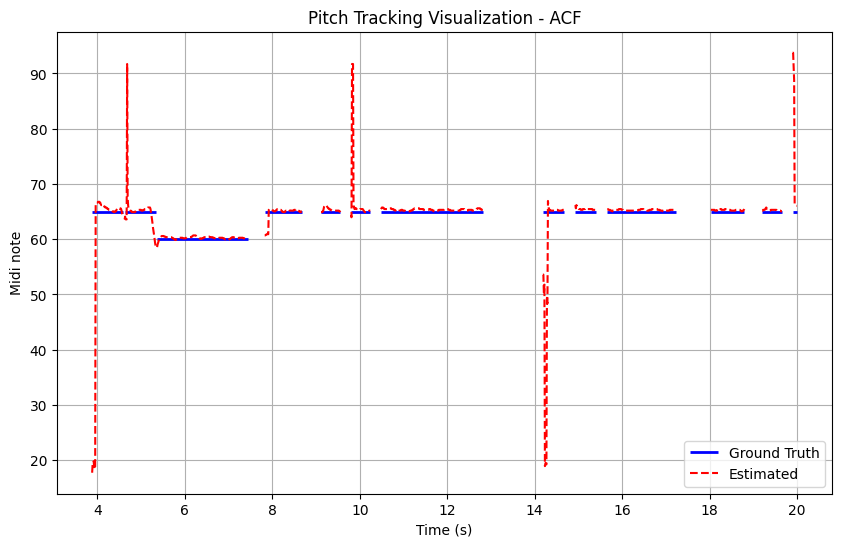

In [6]:
# estimate with computPitch
pitchAlgo = 'TimeAcf' # replace with options: SpectralAcf, SpectralHps, TimeAcf, TimeAmdf, TimeAuditory, TimeZeroCrossings
est_freq_acf, est_time_acf = pyACA.computePitch(pitchAlgo, wav, sr, iBlockLength=4096, iHopLength=512)
est_midi_acf = ToolFreq2Midi(est_freq_acf)

# create mask of where note is active
note_mask = midi_note_mask(midi_data, est_time_acf)
est_midi_masked_acf = np.where(note_mask, est_midi_acf, np.nan)

# convert the pretty midi object to array as ground truth result
midi_pitches, midi_starts, midi_ends = midi_to_array(midi_data)
gt_pitch = np.zeros_like(est_time_acf)
for pitch, start, end in zip(midi_pitches, midi_starts, midi_ends):
    mask = (est_time_acf >= start) & (est_time_acf <= end)
    gt_pitch[mask] = pitch

# visualize
visualizePitchTracking(est_time_acf, gt_pitch, est_time=est_time_acf, est_midi=est_midi_masked_acf, algorithm_name="ACF")

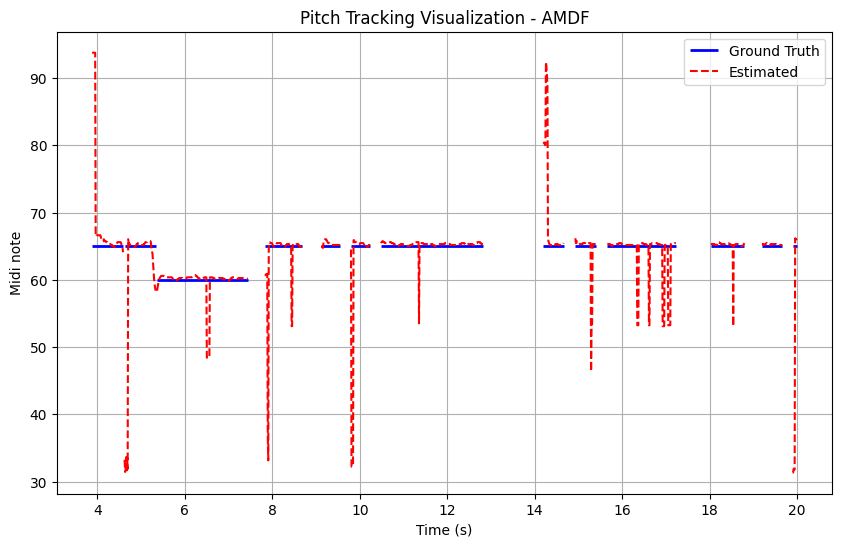

In [7]:
# estimate with TimeAmdf
pitchAlgo = 'TimeAmdf' # replace with options: SpectralAcf, SpectralHps, TimeAcf, TimeAmdf, TimeAuditory, TimeZeroCrossings
est_freq_amdf, est_time_amdf = pyACA.computePitch(pitchAlgo, wav, sr, iBlockLength=4096, iHopLength=512)
est_midi_amdf = ToolFreq2Midi(est_freq_amdf)
# create mask where only note is active
note_mask = midi_note_mask(midi_data, est_time_amdf)
est_midi_masked_amdf = np.where(note_mask, est_midi_amdf, np.nan)
# visualize
visualizePitchTracking(est_time_amdf, gt_pitch, est_time=est_time_amdf, est_midi=est_midi_masked_amdf, algorithm_name="AMDF")

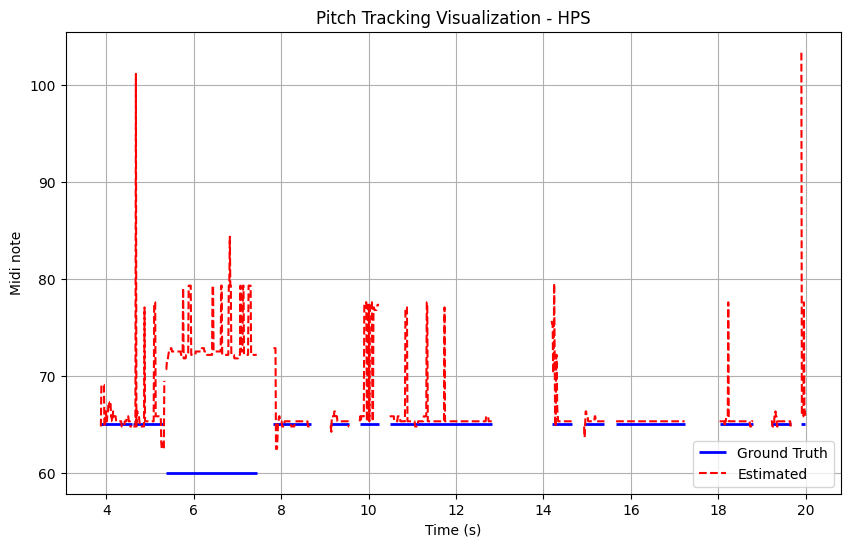

In [8]:
# estimate with SpectralHps
pitchAlgo = 'SpectralHps' # replace with options: SpectralAcf, SpectralHps, TimeAcf, TimeAmdf, TimeAuditory, TimeZeroCrossings
est_freq_hps, est_time_hps = pyACA.computePitch(pitchAlgo, wav, sr, iBlockLength=4096, iHopLength=512)
est_midi_hps = ToolFreq2Midi(est_freq_hps)

# mask where only note is active
est_midi_masked_hps = np.where(note_mask, est_midi_hps, np.nan)
# visualize
visualizePitchTracking(est_time_hps, gt_pitch, est_time=est_time_hps, est_midi=est_midi_masked_hps, algorithm_name="HPS")

Visually, the plots for ACF and AMDF are very similar, both showing tight tracking during active speech and similar failure spikes in silence. They are both excellent at finding the period of the quasi-periodic vocal waveform.

HPS is noticeably noisier during the sustained notes. Looking at the plot for the HPS result, there are times (e.g., $t \approx 5.5-8.0 \text{ s}$ and $t \approx 10.0-13.0 \text{ s}$) where the estimated red line is consistently tracking too high (e.g., between MIDI 70 and 80) even when the ground truth is MIDI 60-65. This confirms that HPS is mistakenly locking onto a stronger harmonic during sustained vowel sounds, which dramatically increases its RMS error.

# 3. Evaluation

## 3.1 RMS error
To quantitatively assess the performance of our pitch estimation algorithm, we evaluated the difference between the estimated and ground-truth fundamental frequencies in the pitch (MIDI) domain.
Because pitch perception is logarithmic, we first converted all frequency values (in Hz) to MIDI note numbers using [``ToolFreq2Midi``](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/ToolFreq2Midi.py).
We then computed the root mean square error (RMSE) in semitones,

$$\left( \frac{1}{N} \sum_{i=1}^{N} e_i^2 \right)^{1/2}$$

where $e_i$ is the pitch estimation error (in cents or semitones) for frame $i$, and $ N $ is the total number of valid frames.

RMS error is a good metric because it provides a scale-independent, perceptually meaningful, and statistically robust measure of pitch estimation accuracy.
It punishes large deviations (octave flips, wrong partials) more heavily while still capturing small-scale fluctuations, making it an ideal summary statistic for continuous $F_0$ tracking evaluation.

Therefore, the evaluation ensures that the results are not biased by absolute frequency magnitude and reflect true perceptual deviations from the reference pitch.


In [9]:
from utils.eval import eval_pitchtrack_midi

rms_acf = eval_pitchtrack_midi(est_midi_masked_acf, gt_pitch)
rms_amdf = eval_pitchtrack_midi(est_midi_masked_amdf, gt_pitch)
rms_hps = eval_pitchtrack_midi(est_midi_masked_hps, gt_pitch)

print('RMS error of ACF algo: ', rms_acf , " cents")
print('RMS error of AMDF algo: ', rms_amdf , " cents")
print('RMS error of HPS algo: ', rms_hps , " cents")

RMS error of ACF algo:  555.4128605917793  cents
RMS error of AMDF algo:  579.0610941150582  cents
RMS error of HPS algo:  651.9255319922759  cents


From the RMS value, we can know that the ACF has best performance, then folloed by AMDF and HPS has the worst performance. Though visually ACF and AMDF fit the ground truth value very well, there are still high RMS error around 555-579 cents. This is because there are outliers of silence and noise. The major errors stem from the tracker locking onto noise or spurious high frequencies during silent gaps and transitions. Also, Human voice pitch is naturally unstable, containing vibrato and slight intonation drift, which increases the ground truth difference and therefore the RMS, even if the algorithm is musically correct. For HPS, as we observed from figure, HPS relies on the precise alignment of harmonic peaks. If the vocal pitch is slightly wavering or inharmonic, the multiplication step in HPS fails to produce a single, distinct peak, leading HPS to jump to a stronger, but incorrect, harmonic.

## 3.2 Estimation Accuracy
In pitch estimation evaluation, we also measure how accurately an algorithm can predict the true fundamental frequency across time. First, we rounded the estimation midi value to closest integer because only integer midi values are meaningful in real cases. The simplest way it to count how often the estimated pitch matches the ground-truth pitch:  $$Accuracy = \frac{Correct\_estimation}{Ground \_truth}$$

However, as we saw in the AMDF and HPS cases earlier, pitch-tracking algorithms often make octave errors, where the estimated pitch is exactly one or more octaves (±12, ±24, … semitones) away from the true pitch. These errors reflect ambiguity in harmonic structure rather than complete misprediction. Therefore, we also calculate the accuracy which we exclude such octave errors. It is simply: $$Accuracy = \frac{Correct\_estimation - octave\_error\_frame}{Ground \_truth - octave\_error\_frame}$$

In this case, accuracy with octave errors reflects strict overall precision, while accuracy without octave errors isolates the algorithm’s ability to identify the correct pitch irrespective of octave ambiguity.

In [13]:
from utils.eval import eval_midi_est_accuracy

acf_acc, acf_acc_no_oct = eval_midi_est_accuracy(est_midi_masked_acf, gt_pitch)
amdf_acc, amdf_acc_no_oct = eval_midi_est_accuracy(est_midi_masked_amdf, gt_pitch)
hps_acc, hps_acc_no_oct = eval_midi_est_accuracy(est_midi_masked_hps, gt_pitch)

print("ACF algorithm's estimation accuracy: ", acf_acc, ", without octave error's accuracy: ", acf_acc_no_oct)
print("AMDF algorithm's estimation accuracy: ", amdf_acc, ", without octave error's accuracy: ", amdf_acc_no_oct)
print("HPS algorithm's estimation accuracy: ", hps_acc, ", without octave error's accuracy: ", hps_acc_no_oct)

ACF algorithm's estimation accuracy:  0.824773413897281 , without octave error's accuracy:  0.8256048387096774
AMDF algorithm's estimation accuracy:  0.797583081570997 , without octave error's accuracy:  0.8190279214064116
HPS algorithm's estimation accuracy:  0.6374622356495468 , without octave error's accuracy:  0.7682038834951457


ACF achieves the highest strict accuracy around 0.8248 and also the highest accuracy of 0.8256 after removing octave errors, indicating that it tracks stable, harmonic keyboard tones reliably and with fewer octave confusions. 

AMDF performs slightly worse than ACF in strict accuracy - 0.7976 overall accuracy but improves noticeably once octave errors are excluded - 0.8190, suggesting it predicts the correct pitch class often but is more susceptible to octave jumps. 

HPS has the worst accuracy around 0.6375, and shows significant improvement after removing octave errors(which achieved 0.7682). This is may be that electric-keyboard tones contain fewer higher harmonics than acoustic instruments, which reduces the advantage of harmonic product analysis and leads to more errors and octave confusions.

verall, ACF is the most stable and accurate for clean, steady keyboard tones, AMDF is moderately reliable but octave-prone, and HPS is less suitable for this particular audio source due to its reliance on strong harmonic structure.


Therefore, we can summarize when to use these 3 algorithms respectively:

- ACF is highly effective at finding the period of a repetitive waveform, natural, harmonic sounds as well as noisy or reverberant environments

- AMDF could be use when computational simplicity is prioritized since it computes absolute differences rather than correlations

- HPS should applied in the situation of complex, polyharmonic sounds with strong overtones and cases which is stable in frequency-domain.

